# Introduction to netCDF and xarray

## Learning Objectives
- Describe the netcdf data format as it is used to store climate data
- Describe how xarray can be used to read netCDF files
- Learn how to create well-formatted datasets from numpy arrays
- Lean how to save xarray datasets as netCDF files

## What is netCDF Data?
NetCDF (network Common Data Form) is a hierarchical data format. It is what is known as a “self-describing” data structure which means that metadata, or descriptions of the data, are included in the file itself and can be parsed programmatically, meaning that they can be accessed using code dto build automated and reproducible workflows.

The NetCDF format can store data with multiple dimensions. It can also store different types of data through arrays that can contain geospatial imagery, rasters, terrain data, climate data, and text. These arrays support metadata, making the netCDF format highly flexible. NetCDF was developed and is supported by [UCAR](https://www.ucar.edu/) who maintains standards and software that support the use of the format.

### Data in netCDF format is:

- **Self-Describing**. A netCDF file includes information about the data it contains.
- **Portable**. A netCDF file can be accessed by computers with different ways of storing integers, characters, and floating-point numbers.
- **Scalable**. Small subsets of large datasets in various formats may be accessed efficiently through netCDF interfaces, even from remote servers.
- **Appendable**. Data may be appended to a properly structured netCDF file without copying the dataset or redefining its structure.
- **Sharable**. One writer and multiple readers may simultaneously access the same netCDF file.
- **Archivable**. Access to all earlier forms of netCDF data will be supported by current and future versions of the software.

### NetCDF4 Format for Climate Data
The hierarchical and flexible nature of netcdf files supports storing data in many different ways. The netCDF4 data standard is used broadly by the climate science community to store climate data. Climate data are:

- often delivered in a time series format (months and years of historic or future projected data).
- spatial in nature, covering regions such as the United States or even the world.
- driven by models which require documentation making the self describing aspect of netCDF files useful.


## Xarray

In the previous set of lectures, we saw how Pandas provided a way to keep track of additional “metadata” surrounding tabular datasets, including “indexes” for each row and labels for each column. These features, together with Pandas’ many useful routines for all kinds of data munging and analysis, have made Pandas one of the most popular python packages in the world.

However, not all Earth science datasets easily fit into the “tabular” model (i.e. rows and columns) imposed by Pandas. In particular, we often deal with multidimensional data. By multidimensional data (also often called N-dimensional), I mean data with many independent dimensions or axes. For example, we might represent Earth’s surface temperature $T$ as a three dimensional variable

$$
T(x, y, t)
$$

where 
$x$ is longitude, $y$ is latitude, and $y$ is time.

The point of xarray is to provide pandas-level convenience for working with this type of data.

![](https://docs.xarray.dev/en/stable/_images/dataset-diagram.png)

### Xarray data structures

Like Pandas, xarray has two fundamental data structures:

- a `DataArray`, which holds a single multi-dimensional variable and its coordinates

- a `Dataset`, which holds multiple variables that potentially share the same coordinates

### DataArray
A DataArray has four essential attributes:

- `values`: a `numpy.ndarray` holding the array’s values

- `dims`: dimension names for each axis (e.g., ('x', 'y', 'z'))

- `coords`: a dict-like container of arrays (coordinates) that label each point (e.g., 1-dimensional arrays of numbers, datetime objects or strings)

- `attrs`: an `OrderedDict` to hold arbitrary metadata (attributes)

Let’s start by constructing some DataArrays manually

## The Argo program

We will get some practice with `xarray` using data from [Argo floats](https://argo.ucsd.edu/)

![](https://argo.ucsd.edu/wp-content/uploads/sites/361/2020/03/APEX_world_HJF-225x300.jpg)

Data from Argo floats are available from several data centers. Here, we will use the data available form the French Institure for Ocean Research [IFREMER](https://data-argo.ifremer.fr/)


In [46]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt

import cartopy.crs as ccrs

In [47]:
# We use xarray.load_dataset to load our profile data 
ds_raw = xr.load_dataset('../data/5901429_prof.nc')

xarray will read the netCDF data as an `xarray.Dataset` object. Below, we see that our dataset has 64 variables and 5 dimension. Looking at the file's Attributes it becomes clear what we mean by metadata and self-describing.

In [48]:
ds_raw

<xarray.Dataset> Size: 1MB
Dimensions:                       (N_PROF: 190, N_PARAM: 3, N_LEVELS: 84,
                                   N_CALIB: 1, N_HISTORY: 0)
Dimensions without coordinates: N_PROF, N_PARAM, N_LEVELS, N_CALIB, N_HISTORY
Data variables: (12/64)
    DATA_TYPE                     object 8B b'Argo profile    '
    FORMAT_VERSION                object 8B b'3.1 '
    HANDBOOK_VERSION              object 8B b'1.2 '
    REFERENCE_DATE_TIME           object 8B b'19500101000000'
    DATE_CREATION                 object 8B b'20070103222401'
    DATE_UPDATE                   object 8B b'20191030224729'
    ...                            ...
    HISTORY_ACTION                (N_HISTORY, N_PROF) object 0B 
    HISTORY_PARAMETER             (N_HISTORY, N_PROF) object 0B 
    HISTORY_START_PRES            (N_HISTORY, N_PROF) float32 0B 
    HISTORY_STOP_PRES             (N_HISTORY, N_PROF) float32 0B 
    HISTORY_PREVIOUS_VALUE        (N_HISTORY, N_PROF) float32 0B 
    HISTORY_QCTEST                (N_HISTORY, N_PROF) object 0B 
Attributes:
    title:                Argo float vertical profile
    institution:          FR GDAC
    source:               Argo float
    history:              2019-10-30T22:47:29Z creation
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  3.1
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile

Similarly to `pandas`, we can visualize the data directly from `xarray`. Below, we use the "dot" notation to access the variable `TEMP_ADJUSTED` and make a plot. Note that xarray used the metadata to already add information to the plot in the form of axes labels (it shows even the units 🤯)

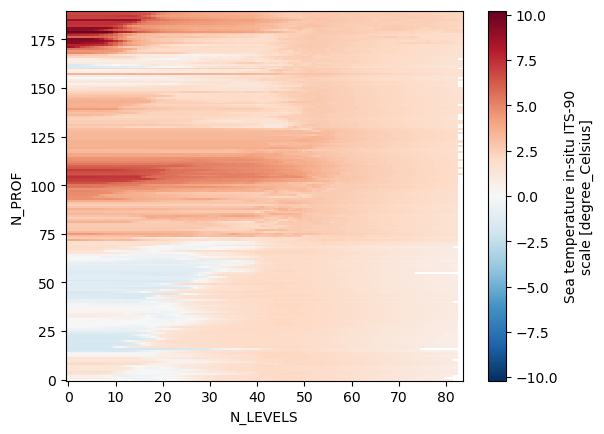

In [49]:
ds_raw.TEMP_ADJUSTED.plot()

What we have here is sea temperature as a function of N_LEVELS and N_RPOFILES. This is not very intuitive. Maybe it would make more sense to analize temperature as a function of depth and time. Also, we don't need all variables from this files and the variable names are a bit annoying to type. Let's go head and do some data cleanup.

In [50]:
# Define a list with the variables that we want to keep
variables = ['PRES_ADJUSTED','TEMP_ADJUSTED', 'PSAL_ADJUSTED', 'LATITUDE', 'LONGITUDE', 'JULD']
# Select only these variables from the whole dataset
ds = ds_raw[variables]
ds

<xarray.Dataset> Size: 196kB
Dimensions:        (N_PROF: 190, N_LEVELS: 84)
Dimensions without coordinates: N_PROF, N_LEVELS
Data variables:
    PRES_ADJUSTED  (N_PROF, N_LEVELS) float32 64kB 5.0 10.0 ... 2.05e+03 2.1e+03
    TEMP_ADJUSTED  (N_PROF, N_LEVELS) float32 64kB 0.146 0.144 ... 2.212 2.187
    PSAL_ADJUSTED  (N_PROF, N_LEVELS) float32 64kB 33.79 33.79 ... 34.77 34.77
    LATITUDE       (N_PROF) float64 2kB -62.06 -62.19 -62.36 ... -46.65 -46.88
    LONGITUDE      (N_PROF) float64 2kB 165.1 165.7 166.8 ... -27.49 -27.41
    JULD           (N_PROF) datetime64[ns] 2kB 2006-12-28T01:30:26 ... 2012-0...
Attributes:
    title:                Argo float vertical profile
    institution:          FR GDAC
    source:               Argo float
    history:              2019-10-30T22:47:29Z creation
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  3.1
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile

Now, we can rename variables in `xarray`, using the method `rename` and passing the current variable names and the respective new variable names in the form of a dictionary `{'current_name1':'new_name1', 'current_name2':'new_name2'}`. For example

In [51]:
ds = ds.rename({'JULD':'time'})
ds

<xarray.Dataset> Size: 196kB
Dimensions:        (N_PROF: 190, N_LEVELS: 84)
Dimensions without coordinates: N_PROF, N_LEVELS
Data variables:
    PRES_ADJUSTED  (N_PROF, N_LEVELS) float32 64kB 5.0 10.0 ... 2.05e+03 2.1e+03
    TEMP_ADJUSTED  (N_PROF, N_LEVELS) float32 64kB 0.146 0.144 ... 2.212 2.187
    PSAL_ADJUSTED  (N_PROF, N_LEVELS) float32 64kB 33.79 33.79 ... 34.77 34.77
    LATITUDE       (N_PROF) float64 2kB -62.06 -62.19 -62.36 ... -46.65 -46.88
    LONGITUDE      (N_PROF) float64 2kB 165.1 165.7 166.8 ... -27.49 -27.41
    time           (N_PROF) datetime64[ns] 2kB 2006-12-28T01:30:26 ... 2012-0...
Attributes:
    title:                Argo float vertical profile
    institution:          FR GDAC
    source:               Argo float
    history:              2019-10-30T22:47:29Z creation
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  3.1
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile

Now, let's do this for the othe variables 

In [52]:
ds = ds.rename({'PRES_ADJUSTED':'pressure', 'TEMP_ADJUSTED':'temperature',
               'PSAL_ADJUSTED':'salinity', 'LATITUDE':'latitude',
                'LONGITUDE':'longitude'})
ds

<xarray.Dataset> Size: 196kB
Dimensions:      (N_PROF: 190, N_LEVELS: 84)
Dimensions without coordinates: N_PROF, N_LEVELS
Data variables:
    pressure     (N_PROF, N_LEVELS) float32 64kB 5.0 10.0 ... 2.05e+03 2.1e+03
    temperature  (N_PROF, N_LEVELS) float32 64kB 0.146 0.144 ... 2.212 2.187
    salinity     (N_PROF, N_LEVELS) float32 64kB 33.79 33.79 ... 34.77 34.77
    latitude     (N_PROF) float64 2kB -62.06 -62.19 -62.36 ... -46.65 -46.88
    longitude    (N_PROF) float64 2kB 165.1 165.7 166.8 ... -27.41 -27.49 -27.41
    time         (N_PROF) datetime64[ns] 2kB 2006-12-28T01:30:26 ... 2012-06-...
Attributes:
    title:                Argo float vertical profile
    institution:          FR GDAC
    source:               Argo float
    history:              2019-10-30T22:47:29Z creation
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  3.1
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile

In [53]:
ds.temperature

<xarray.DataArray 'temperature' (N_PROF: 190, N_LEVELS: 84)> Size: 64kB
array([[0.146, 0.144, 0.145, ..., 0.759,   nan,   nan],
       [0.681, 0.683, 0.668, ...,   nan,   nan,   nan],
       [0.564, 0.565, 0.564, ..., 0.742,   nan,   nan],
       ...,
       [6.965, 6.965, 6.964, ..., 2.253, 2.252, 2.207],
       [6.819, 6.819, 6.82 , ..., 2.267, 2.243, 2.233],
       [6.636, 6.637, 6.638, ..., 2.275, 2.212, 2.187]],
      shape=(190, 84), dtype=float32)
Dimensions without coordinates: N_PROF, N_LEVELS
Attributes:
    long_name:       Sea temperature in-situ ITS-90 scale
    standard_name:   sea_water_temperature
    units:           degree_Celsius
    valid_min:       -2.5
    valid_max:       40.0
    C_format:        %9.3f
    FORTRAN_format:  F9.3
    resolution:      0.001

We have succefully changed the variable names. Now, we see that the dataset dimensions are profile number and level number (N_PROF, N_LEVELS), but we would prefer to have time as a dimension. We can swap the dimension `N_PROF` with `time`

In [54]:
ds = ds.swap_dims({'N_PROF':'time'})
ds

<xarray.Dataset> Size: 196kB
Dimensions:      (time: 190, N_LEVELS: 84)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2006-12-28T01:30:26 ... 2012-06-18...
Dimensions without coordinates: N_LEVELS
Data variables:
    pressure     (time, N_LEVELS) float32 64kB 5.0 10.0 ... 2.05e+03 2.1e+03
    temperature  (time, N_LEVELS) float32 64kB 0.146 0.144 0.145 ... 2.212 2.187
    salinity     (time, N_LEVELS) float32 64kB 33.79 33.79 33.79 ... 34.77 34.77
    latitude     (time) float64 2kB -62.06 -62.19 -62.36 ... -46.65 -46.88
    longitude    (time) float64 2kB 165.1 165.7 166.8 ... -27.41 -27.49 -27.41
Attributes:
    title:                Argo float vertical profile
    institution:          FR GDAC
    source:               Argo float
    history:              2019-10-30T22:47:29Z creation
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  3.1
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile

Nice! Now, if we try to plot temperature `xarray` will disply it as a function of time.

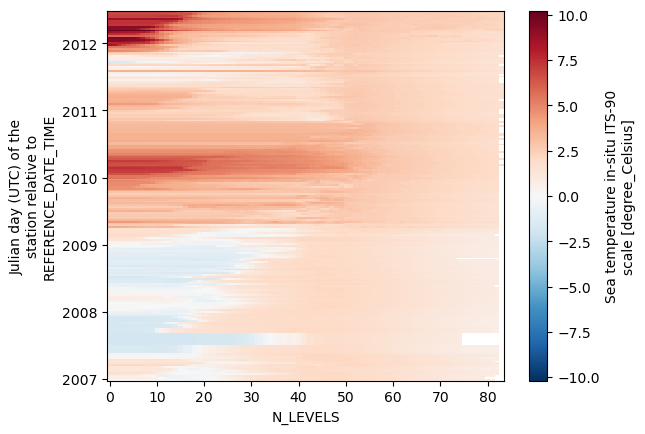

In [55]:
ds.temperature.plot()

### Operations in xarray are dimension aware

- Back when we were using numpy, if we wanted to perform an operation on a given array, we had to specify the axis on which to operate. For example, `np.mean(data, axis=1)`. In `xarray` this is much more intuitive: you specify the dimension on which we want to operate.

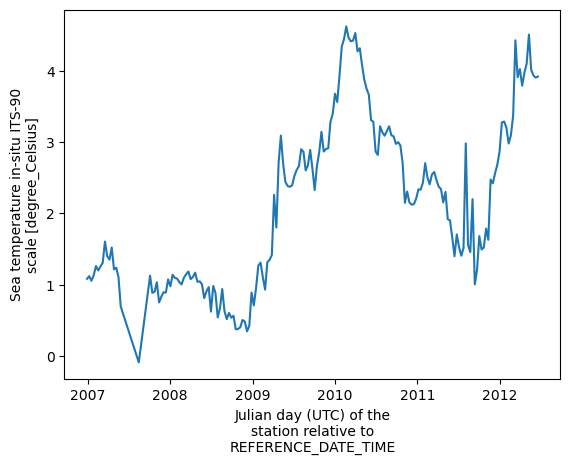

In [56]:
ds.temperature.mean(dim='N_LEVELS').plot()

#### 🤔 Pressure or depth?
- The pressure in this file is given in decibar. Discuss with your peers what is a decibar and how it relates to depth.
- It seems like the pressure values in your dataset are not exactly the same for each profile. Discuss with your peers some strategies the you could use to have a comon range of depths for all profiles and map the dimension 'N_LEVELS' to depth in your dataset. 

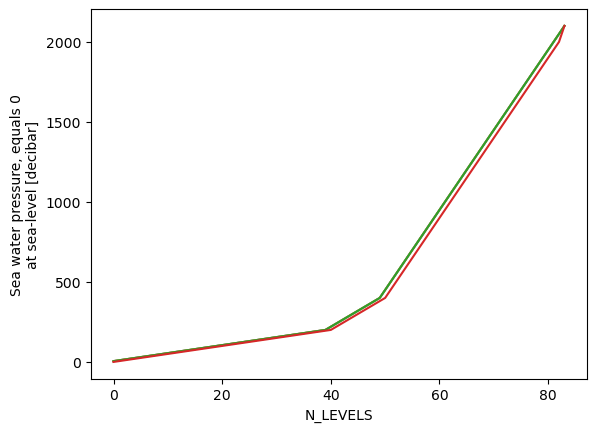

In [57]:
# Hide this cell
ds.pressure.mean(dim='time').plot()
ds.pressure.median(dim='time').plot()
ds.pressure.max(dim='time').plot()
ds.pressure.min(dim='time').plot()

In [58]:
depths = ds.pressure.median(dim='time')
ds['depth'] = depths
ds = ds.swap_dims({'N_LEVELS':'depth'})
ds

<xarray.Dataset> Size: 196kB
Dimensions:      (time: 190, depth: 84)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2006-12-28T01:30:26 ... 2012-06-18...
  * depth        (depth) float32 336B 5.0 10.0 15.0 ... 2e+03 2.05e+03 2.1e+03
Data variables:
    pressure     (time, depth) float32 64kB 5.0 10.0 15.0 ... 2.05e+03 2.1e+03
    temperature  (time, depth) float32 64kB 0.146 0.144 0.145 ... 2.212 2.187
    salinity     (time, depth) float32 64kB 33.79 33.79 33.79 ... 34.77 34.77
    latitude     (time) float64 2kB -62.06 -62.19 -62.36 ... -46.65 -46.88
    longitude    (time) float64 2kB 165.1 165.7 166.8 ... -27.41 -27.49 -27.41
Attributes:
    title:                Argo float vertical profile
    institution:          FR GDAC
    source:               Argo float
    history:              2019-10-30T22:47:29Z creation
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  3.1
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile

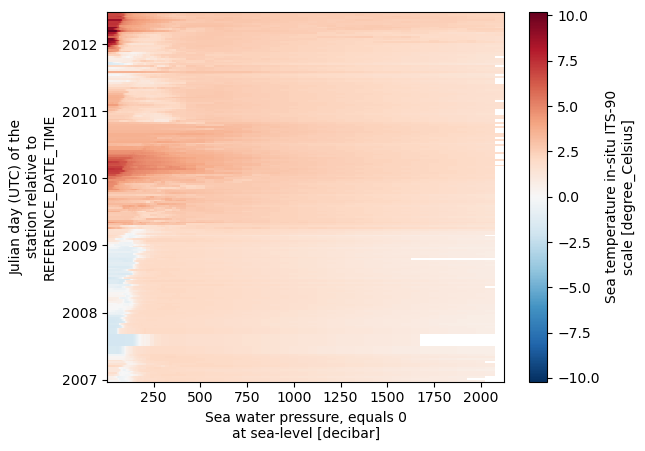

In [59]:
ds.temperature.plot()

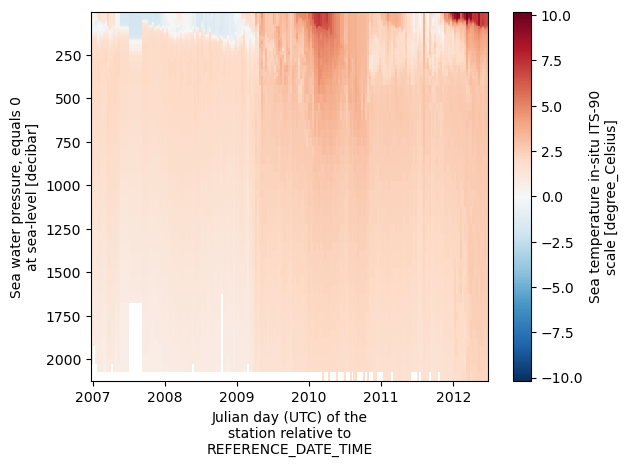

In [60]:
ds.temperature.plot(x='time', y='depth', yincrease=False)

### Data selection in xarray

Similarly to pandas `loc` and `iloc`, in xarray you can select data by index or by the actual value of the data. For example: 

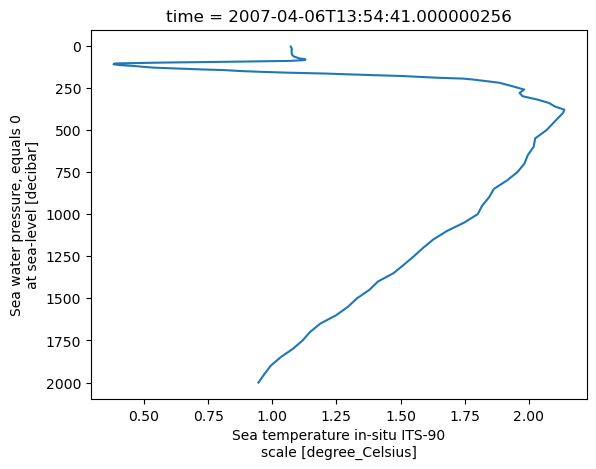

In [61]:
ds.temperature.isel(time=10).plot(y='depth', yincrease=False)

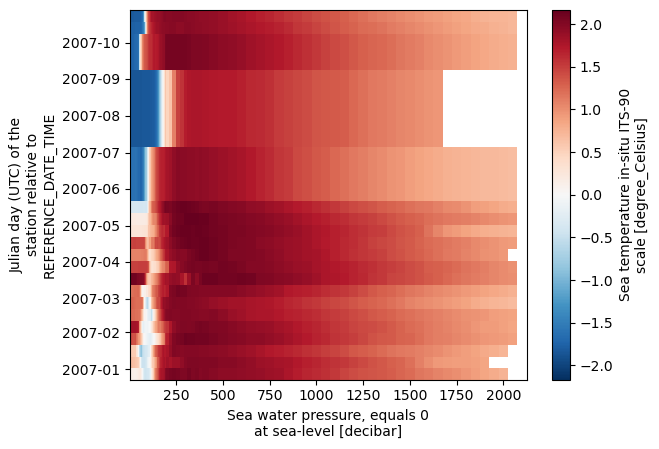

In [62]:
# You can also ask for a slice
ds.temperature.isel(time=slice(0, 20)).plot()

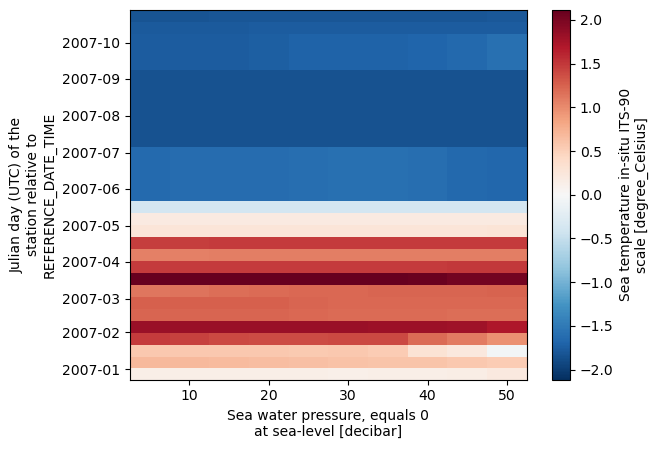

In [63]:
# Which also works with multiple dimensions
ds.temperature.isel(time=slice(0, 20), depth=slice(0, 10)).plot()

In [64]:
ds.temperature.sel(time="2007-01-15")

<xarray.DataArray 'temperature' (time: 0, depth: 84)> Size: 0B
array([], shape=(0, 84), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 0B 
  * depth    (depth) float32 336B 5.0 10.0 15.0 20.0 ... 2e+03 2.05e+03 2.1e+03
Attributes:
    long_name:       Sea temperature in-situ ITS-90 scale
    standard_name:   sea_water_temperature
    units:           degree_Celsius
    valid_min:       -2.5
    valid_max:       40.0
    C_format:        %9.3f
    FORTRAN_format:  F9.3
    resolution:      0.001

In [65]:
ds.temperature.sel(time="2007-01-15", method='nearest')

<xarray.DataArray 'temperature' (depth: 84)> Size: 336B
array([ 0.564,  0.565,  0.564,  0.563,  0.56 ,  0.562,  0.536,  0.312,
        0.225, -0.052, -0.534, -0.748, -0.848, -0.582, -0.481, -0.454,
       -0.405, -0.382, -0.332, -0.242, -0.206,  0.081,  0.263,  0.423,
        0.605,  0.87 ,  1.061,  1.255,  1.321,  1.404,  1.544,  1.576,
        1.59 ,  1.629,  1.732,  1.778,  1.739,  1.715,  1.739,  1.781,
        1.907,  2.   ,  1.983,  1.97 ,  1.995,  1.993,  1.993,  1.981,
        1.973,  1.968,  1.956,  1.943,  1.9  ,  1.865,  1.833,  1.782,
        1.736,  1.694,  1.658,  1.626,  1.579,  1.546,  1.503,  1.456,
        1.409,  1.352,  1.313,  1.272,  1.228,  1.183,  1.146,  1.123,
        1.089,  1.061,  1.015,  0.974,  0.936,  0.908,  0.869,  0.825,
        0.794,  0.742,    nan,    nan], dtype=float32)
Coordinates:
  * depth    (depth) float32 336B 5.0 10.0 15.0 20.0 ... 2e+03 2.05e+03 2.1e+03
    time     datetime64[ns] 8B 2007-01-16T13:35:59
Attributes:
    long_name:       Sea temperature in-situ ITS-90 scale
    standard_name:   sea_water_temperature
    units:           degree_Celsius
    valid_min:       -2.5
    valid_max:       40.0
    C_format:        %9.3f
    FORTRAN_format:  F9.3
    resolution:      0.001

## Creating Xarray atasets

### A Comparison to Numpy

Remembering we looked at data for the maximum recorded temperature at the Denver Water Department for a number of years. You used numpy to load the dataset as an array, and performed operations like taking the mean and standard deviation on various axes of the data. Let's say we want to do this with xarray datasets instead of numpy arrays. We used `np.loadtxt()` to load the data as a numpy dataset, so lets try using the function we learned last lecture (`xr.load_dataset()`) to open the data as an xarray dataset.

In [66]:
xr.load_dataset('../data/meteo_denver_tmax_2000_2022.txt')

ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4', 'scipy']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html

Why didn't this command work? Because xarray uses the netCDF data format, which is a special way of encoding and saving data. NetCDF files are saved with the `.nc` extension. So xarray doesn't know what to do with a `.txt` file. If we want to make this data into an xarray dataset, we will need to do it ourselves.

### DataArrays

One of the simplest ways to make a numpy array is to create it from a list:

In [68]:
np.array([0,1,2])

array([0, 1, 2])

In the same way, we can make a DataArray from a numpy array using the command `xr.DataArray()`. If you recall, a data array takes a single numpy array and "wraps" it so we can using xarray dimensions and coordinates to access it. From the [xarray documentation](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.html), we can see that `xr.DataArray()` takes several arguments. We will go over a few of them here, but as always, refer back to the documentation for a more complete description of the function.

First, let's load our maximum temperature data as a numpy array, and try converting it to a DataArray:

In [70]:
tmax_array = np.loadtxt('../data/meteo_denver_tmax_2000_2022.txt')
tmax_array.shape # To remind us what tmax_array looks like

(23, 12)

In [71]:
tmax_dataArray1 = xr.DataArray(data=tmax_array)
tmax_dataArray1

<xarray.DataArray (dim_0: 23, dim_1: 12)> Size: 2kB
array([[50.9, 56.4, 57.5, 69.3, 78.2, 86. , 94.7, 93. , 81.9, 67.5, 46.2,
        46.1],
       [48.2, 45.4, 54.8, 65.8, 73.8, 87.3, 95.3, 90.6, 86. , 69.7, 61.7,
        50.2],
       [47.7, 51.8, 51.7, 69.7, 73.1, 90.4, 96. , 90.3, 82. , 63.3, 52.3,
        50.6],
       [54.7, 44.7, 54.6, 67.9, 73.8, 80.1, 96.7, 92.4, 79.3, 74.3, 51.4,
        50.2],
       [50.4, 46.5, 63.3, 63.5, 76.7, 80.8, 88.4, 85.9, 80.7, 67.4, 53.4,
        47.7],
       [49.2, 51.2, 55.4, 62.5, 73.8, 84.3, 95.8, 88.2, 83.7, 68.9, 60.3,
        45.2],
       [54.5, 47.8, 53.5, 68.9, 74.9, 87.1, 88. , 83.8, 72. , 60.8, 50. ,
        40.2],
       [30.6, 40.8, 58.5, 61.7, 72.5, 86.5, 92.2, 90.9, 79.5, 66.3, 53.8,
        38.9],
       [40.1, 48.6, 54.8, 63. , 72.5, 85. , 93.9, 86.7, 78.5, 67.7, 64.5,
        44.6],
       [52. , 56.5, 60.5, 61.2, 73.7, 80.6, 87. , 88.4, 79.7, 57.5, 59.5,
        41.3],
...
       [48.6, 46.6, 55.4, 58.3, 73.9, 89.1, 90. , 92.1, 81.9, 63.7, 57.8,
        46.2],
       [49.7, 46.3, 58.5, 66.2, 72.2, 85.1, 89.6, 86.7, 82.7, 73.7, 55.5,
        47.5],
       [48.4, 50. , 60.7, 65.6, 65.5, 86.7, 88.5, 91.2, 88.9, 72.3, 57.5,
        47.8],
       [50.9, 55.1, 58. , 63.1, 69.4, 89.2, 94.1, 89.6, 85. , 75.7, 64.1,
        45. ],
       [44.9, 56.1, 65.5, 65.4, 70.4, 88.1, 91.4, 87.8, 79.7, 66.7, 61.2,
        51.2],
       [51.5, 45.4, 58.8, 65.1, 76.8, 91.9, 92.2, 90.5, 86. , 64.2, 53.5,
        49. ],
       [47.9, 45.7, 53.4, 66.1, 65.8, 83.4, 94.6, 93. , 88.7, 61.9, 53.4,
        48.6],
       [50.2, 44.6, 58.1, 62.9, 77.2, 88.7, 92.8, 94.4, 82.1, 67.5, 61.6,
        49.6],
       [48.9, 42.6, 55.3, 60.7, 70.6, 89. , 93.1, 91.5, 87.5, 71.1, 62.1,
        56.7],
       [47.9, 46.2, 56. , 66.7, 74. , 87.1, 94.2, 92.3, 85.7, 69.5, 50.7,
        47.3]])
Dimensions without coordinates: dim_0, dim_1

In [74]:
tmax_dataArray1.mean(dim='dim_0')

<xarray.DataArray (dim_1: 12)> Size: 96B
array([48.46521739, 47.93913043, 57.72173913, 65.00869565, 72.70434783,
       86.58695652, 92.50869565, 90.35652174, 82.69130435, 67.76956522,
       56.75652174, 47.3826087 ])
Dimensions without coordinates: dim_1

Here we just specified the data argument of `xr.DataArray()`. We did successfully create a DataArray, but it doesn't have most of the things we like about dataArrays and datasets. The dimensions are just `dim_0` and `dim_1`, which doesn't tell us very much more than just using `axis=0` or `axis=1` in a numpy array. We also don't have and coordinates or indexes, so we still have to select our data using its raw position in the array. Finally, we aren't making use of the attributes to communicate more information about our data. In order to fix these, we will have to specify some other arguments of `xr.DataArray()`. Lets start by giving our DataArray some coordinates, corresponding to the months and years our data encompasses. Based on the documentation, we need to make a dictionary in the form `{'dimension_name':array}`.

In [75]:
months = np.array(['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC'])
years = np.arange(2000, 2023)
tmax_dataArray2 = xr.DataArray(data=tmax_array, coords={'year':years, 'month':months})
tmax_dataArray2

<xarray.DataArray (year: 23, month: 12)> Size: 2kB
array([[50.9, 56.4, 57.5, 69.3, 78.2, 86. , 94.7, 93. , 81.9, 67.5, 46.2,
        46.1],
       [48.2, 45.4, 54.8, 65.8, 73.8, 87.3, 95.3, 90.6, 86. , 69.7, 61.7,
        50.2],
       [47.7, 51.8, 51.7, 69.7, 73.1, 90.4, 96. , 90.3, 82. , 63.3, 52.3,
        50.6],
       [54.7, 44.7, 54.6, 67.9, 73.8, 80.1, 96.7, 92.4, 79.3, 74.3, 51.4,
        50.2],
       [50.4, 46.5, 63.3, 63.5, 76.7, 80.8, 88.4, 85.9, 80.7, 67.4, 53.4,
        47.7],
       [49.2, 51.2, 55.4, 62.5, 73.8, 84.3, 95.8, 88.2, 83.7, 68.9, 60.3,
        45.2],
       [54.5, 47.8, 53.5, 68.9, 74.9, 87.1, 88. , 83.8, 72. , 60.8, 50. ,
        40.2],
       [30.6, 40.8, 58.5, 61.7, 72.5, 86.5, 92.2, 90.9, 79.5, 66.3, 53.8,
        38.9],
       [40.1, 48.6, 54.8, 63. , 72.5, 85. , 93.9, 86.7, 78.5, 67.7, 64.5,
        44.6],
       [52. , 56.5, 60.5, 61.2, 73.7, 80.6, 87. , 88.4, 79.7, 57.5, 59.5,
        41.3],
...
       [48.6, 46.6, 55.4, 58.3, 73.9, 89.1, 90. , 92.1, 81.9, 63.7, 57.8,
        46.2],
       [49.7, 46.3, 58.5, 66.2, 72.2, 85.1, 89.6, 86.7, 82.7, 73.7, 55.5,
        47.5],
       [48.4, 50. , 60.7, 65.6, 65.5, 86.7, 88.5, 91.2, 88.9, 72.3, 57.5,
        47.8],
       [50.9, 55.1, 58. , 63.1, 69.4, 89.2, 94.1, 89.6, 85. , 75.7, 64.1,
        45. ],
       [44.9, 56.1, 65.5, 65.4, 70.4, 88.1, 91.4, 87.8, 79.7, 66.7, 61.2,
        51.2],
       [51.5, 45.4, 58.8, 65.1, 76.8, 91.9, 92.2, 90.5, 86. , 64.2, 53.5,
        49. ],
       [47.9, 45.7, 53.4, 66.1, 65.8, 83.4, 94.6, 93. , 88.7, 61.9, 53.4,
        48.6],
       [50.2, 44.6, 58.1, 62.9, 77.2, 88.7, 92.8, 94.4, 82.1, 67.5, 61.6,
        49.6],
       [48.9, 42.6, 55.3, 60.7, 70.6, 89. , 93.1, 91.5, 87.5, 71.1, 62.1,
        56.7],
       [47.9, 46.2, 56. , 66.7, 74. , 87.1, 94.2, 92.3, 85.7, 69.5, 50.7,
        47.3]])
Coordinates:
  * year     (year) int64 184B 2000 2001 2002 2003 2004 ... 2019 2020 2021 2022
  * month    (month) <U3 144B 'JAN' 'FEB' 'MAR' 'APR' ... 'OCT' 'NOV' 'DEC'

In [76]:
tmax_dataArray2.sel(year=2013, month='MAR')

<xarray.DataArray ()> Size: 8B
array(55.4)
Coordinates:
    year     int64 8B 2013
    month    <U3 12B 'MAR'

In [77]:
tmax_dataArray2.mean(dim='year')

<xarray.DataArray (month: 12)> Size: 96B
array([48.46521739, 47.93913043, 57.72173913, 65.00869565, 72.70434783,
       86.58695652, 92.50869565, 90.35652174, 82.69130435, 67.76956522,
       56.75652174, 47.3826087 ])
Coordinates:
  * month    (month) <U3 144B 'JAN' 'FEB' 'MAR' 'APR' ... 'OCT' 'NOV' 'DEC'

This works well! We now have 2 labelled dimensions ("year" and "month") and corresponding indexes that we can use to select datapoints directly by their year and month. We can now do all of the data analysis operations (mean, median, standard deviation) by specifying named dimensions instead of axes, just like you saw in the previous lecture.
- **Note:** There are a lot of different ways to initialize coordinates and dimensions for DataArrays. This is the simplest and most common, where each dimension corresponds to a 1D coordinate array that is used to index your data (Like using x, y, and z values to pick a point in a mathematical function of the form f(x, y, z)). Xarray allows for the flexibility of providing coordinates that correspond to multiple dimensions, dimensions without coordinates, . . . to give more flexibility. We won't go over it here, but if you're curious, check out the documenation, scroll through some examples, and experiment a little to see just how much xarray is capable of.

The final thing we want to add is attributes, so that people can understand what our data means. We do this by passing a dictionary as the argument to `attrs`.

In [78]:
attrs_dict = {'title': 'Max Temperature at Denver Water Department', 'units': 'Degrees Farenheit', 'date_created': '2025-03-20',
              'description': 'Max temp by month and year from 2000 - 2022'}

tmax_dataArray3 = xr.DataArray(data=tmax_array, coords={'year':years, 'month':months}, attrs=attrs_dict)
tmax_dataArray3

<xarray.DataArray (year: 23, month: 12)> Size: 2kB
array([[50.9, 56.4, 57.5, 69.3, 78.2, 86. , 94.7, 93. , 81.9, 67.5, 46.2,
        46.1],
       [48.2, 45.4, 54.8, 65.8, 73.8, 87.3, 95.3, 90.6, 86. , 69.7, 61.7,
        50.2],
       [47.7, 51.8, 51.7, 69.7, 73.1, 90.4, 96. , 90.3, 82. , 63.3, 52.3,
        50.6],
       [54.7, 44.7, 54.6, 67.9, 73.8, 80.1, 96.7, 92.4, 79.3, 74.3, 51.4,
        50.2],
       [50.4, 46.5, 63.3, 63.5, 76.7, 80.8, 88.4, 85.9, 80.7, 67.4, 53.4,
        47.7],
       [49.2, 51.2, 55.4, 62.5, 73.8, 84.3, 95.8, 88.2, 83.7, 68.9, 60.3,
        45.2],
       [54.5, 47.8, 53.5, 68.9, 74.9, 87.1, 88. , 83.8, 72. , 60.8, 50. ,
        40.2],
       [30.6, 40.8, 58.5, 61.7, 72.5, 86.5, 92.2, 90.9, 79.5, 66.3, 53.8,
        38.9],
       [40.1, 48.6, 54.8, 63. , 72.5, 85. , 93.9, 86.7, 78.5, 67.7, 64.5,
        44.6],
       [52. , 56.5, 60.5, 61.2, 73.7, 80.6, 87. , 88.4, 79.7, 57.5, 59.5,
        41.3],
...
       [48.6, 46.6, 55.4, 58.3, 73.9, 89.1, 90. , 92.1, 81.9, 63.7, 57.8,
        46.2],
       [49.7, 46.3, 58.5, 66.2, 72.2, 85.1, 89.6, 86.7, 82.7, 73.7, 55.5,
        47.5],
       [48.4, 50. , 60.7, 65.6, 65.5, 86.7, 88.5, 91.2, 88.9, 72.3, 57.5,
        47.8],
       [50.9, 55.1, 58. , 63.1, 69.4, 89.2, 94.1, 89.6, 85. , 75.7, 64.1,
        45. ],
       [44.9, 56.1, 65.5, 65.4, 70.4, 88.1, 91.4, 87.8, 79.7, 66.7, 61.2,
        51.2],
       [51.5, 45.4, 58.8, 65.1, 76.8, 91.9, 92.2, 90.5, 86. , 64.2, 53.5,
        49. ],
       [47.9, 45.7, 53.4, 66.1, 65.8, 83.4, 94.6, 93. , 88.7, 61.9, 53.4,
        48.6],
       [50.2, 44.6, 58.1, 62.9, 77.2, 88.7, 92.8, 94.4, 82.1, 67.5, 61.6,
        49.6],
       [48.9, 42.6, 55.3, 60.7, 70.6, 89. , 93.1, 91.5, 87.5, 71.1, 62.1,
        56.7],
       [47.9, 46.2, 56. , 66.7, 74. , 87.1, 94.2, 92.3, 85.7, 69.5, 50.7,
        47.3]])
Coordinates:
  * year     (year) int64 184B 2000 2001 2002 2003 2004 ... 2019 2020 2021 2022
  * month    (month) <U3 144B 'JAN' 'FEB' 'MAR' 'APR' ... 'OCT' 'NOV' 'DEC'
Attributes:
    title:         Max Temperature at Denver Water Department
    units:         Degrees Farenheit
    date_created:  2025-03-20
    description:   Max temp by month and year from 2000 - 2022

We have now added attributes that explain what the data is, where it was collected, when the dataset was created, and what the units of our data are. This is very helpful when sharing data, since everything someone needs to understand data is included in the file itself. One last thing to highlight before we move on to Datasets is that we can also add attributes after the fact, using the structure shown below.

In [79]:
tmax_dataArray3.month.attrs['units'] = '3-letter code for months'
tmax_dataArray3

<xarray.DataArray (year: 23, month: 12)> Size: 2kB
array([[50.9, 56.4, 57.5, 69.3, 78.2, 86. , 94.7, 93. , 81.9, 67.5, 46.2,
        46.1],
       [48.2, 45.4, 54.8, 65.8, 73.8, 87.3, 95.3, 90.6, 86. , 69.7, 61.7,
        50.2],
       [47.7, 51.8, 51.7, 69.7, 73.1, 90.4, 96. , 90.3, 82. , 63.3, 52.3,
        50.6],
       [54.7, 44.7, 54.6, 67.9, 73.8, 80.1, 96.7, 92.4, 79.3, 74.3, 51.4,
        50.2],
       [50.4, 46.5, 63.3, 63.5, 76.7, 80.8, 88.4, 85.9, 80.7, 67.4, 53.4,
        47.7],
       [49.2, 51.2, 55.4, 62.5, 73.8, 84.3, 95.8, 88.2, 83.7, 68.9, 60.3,
        45.2],
       [54.5, 47.8, 53.5, 68.9, 74.9, 87.1, 88. , 83.8, 72. , 60.8, 50. ,
        40.2],
       [30.6, 40.8, 58.5, 61.7, 72.5, 86.5, 92.2, 90.9, 79.5, 66.3, 53.8,
        38.9],
       [40.1, 48.6, 54.8, 63. , 72.5, 85. , 93.9, 86.7, 78.5, 67.7, 64.5,
        44.6],
       [52. , 56.5, 60.5, 61.2, 73.7, 80.6, 87. , 88.4, 79.7, 57.5, 59.5,
        41.3],
...
       [48.6, 46.6, 55.4, 58.3, 73.9, 89.1, 90. , 92.1, 81.9, 63.7, 57.8,
        46.2],
       [49.7, 46.3, 58.5, 66.2, 72.2, 85.1, 89.6, 86.7, 82.7, 73.7, 55.5,
        47.5],
       [48.4, 50. , 60.7, 65.6, 65.5, 86.7, 88.5, 91.2, 88.9, 72.3, 57.5,
        47.8],
       [50.9, 55.1, 58. , 63.1, 69.4, 89.2, 94.1, 89.6, 85. , 75.7, 64.1,
        45. ],
       [44.9, 56.1, 65.5, 65.4, 70.4, 88.1, 91.4, 87.8, 79.7, 66.7, 61.2,
        51.2],
       [51.5, 45.4, 58.8, 65.1, 76.8, 91.9, 92.2, 90.5, 86. , 64.2, 53.5,
        49. ],
       [47.9, 45.7, 53.4, 66.1, 65.8, 83.4, 94.6, 93. , 88.7, 61.9, 53.4,
        48.6],
       [50.2, 44.6, 58.1, 62.9, 77.2, 88.7, 92.8, 94.4, 82.1, 67.5, 61.6,
        49.6],
       [48.9, 42.6, 55.3, 60.7, 70.6, 89. , 93.1, 91.5, 87.5, 71.1, 62.1,
        56.7],
       [47.9, 46.2, 56. , 66.7, 74. , 87.1, 94.2, 92.3, 85.7, 69.5, 50.7,
        47.3]])
Coordinates:
  * year     (year) int64 184B 2000 2001 2002 2003 2004 ... 2019 2020 2021 2022
  * month    (month) <U3 144B 'JAN' 'FEB' 'MAR' 'APR' ... 'OCT' 'NOV' 'DEC'
Attributes:
    title:         Max Temperature at Denver Water Department
    units:         Degrees Farenheit
    date_created:  2025-03-20
    description:   Max temp by month and year from 2000 - 2022

This structure also allows us to add attributes to specific variables or coordinates to add further clarification. In the example above, I added an attribute to the month coordinate specifically, to clarify that months were indexed as 3-letter strings.

### Datasets
If a DataArray corresponds to a single numpy array, a Dataset is a collection of several numpy arrays of the same shape. Datasets can store multiple variables that have the same dimensions and coordinates together. To explore how to create them, lets load a few more meteorological arrays:

In [80]:
precip_array = np.loadtxt('../data/meteo_denver_precip_2000_2022.txt')
snow_array = np.loadtxt('../data/meteo_denver_snow_2000_2022.txt')

As always, we follow the [xarray documentation for Datasets](https://docs.xarray.dev/en/stable/generated/xarray.Dataset.html). The simplest way to initialize a Dataset is to give it a few well-formatted DataArrays to stack together. To see this, lets turn our precipitation and snowfall into some well formated dataArrays, and pass them to `xr.Dataset()` as data variables.

In [81]:
precip_attrs_dict = {'title': 'Precipitation at Denver Water Department', 'units': 'inches', 'date_created': '2025-03-20',
              'description': 'Precipitation by month and year from 2000 - 2022'}
precip_dataArray = xr.DataArray(data=precip_array, coords={'year':years, 'month':months}, attrs=precip_attrs_dict)

snow_attrs_dict = {'title': 'Snowfall at Denver Water Department', 'units': 'inches', 'date_created': '2025-03-20',
              'description': 'Total Snow Accumulation by month and year from 2000 - 2022'}
snow_dataArray = xr.DataArray(data=snow_array, coords={'year':years, 'month':months}, attrs=snow_attrs_dict)

meteo_ds1 = xr.Dataset(data_vars={'max_temp':tmax_dataArray3, 'precip':precip_dataArray, 'snow':snow_dataArray})
meteo_ds1

<xarray.Dataset> Size: 7kB
Dimensions:   (year: 23, month: 12)
Coordinates:
  * year      (year) int64 184B 2000 2001 2002 2003 2004 ... 2019 2020 2021 2022
  * month     (month) <U3 144B 'JAN' 'FEB' 'MAR' 'APR' ... 'OCT' 'NOV' 'DEC'
Data variables:
    max_temp  (year, month) float64 2kB 50.9 56.4 57.5 69.3 ... 69.5 50.7 47.3
    precip    (year, month) float64 2kB 0.5 0.27 1.47 1.28 ... 0.77 0.48 1.43
    snow      (year, month) float64 2kB 4.4 1.8 13.4 3.3 ... 0.0 -999.0 8.1 10.6

This works pretty well. Our dataset is well formatted, with "year" and "month" as indexed coordinates, and all of our DataArrays as variables. Xarray even kept our attributes, bundling them into each variable. However, creating DataArrays for each array, then using those DataArrays to make a Dataset is rather inefficient. By using a few more arguments of `xr.Dataset()`, we can do the whole thing in one go. To do this, we need to use `coords` as well as `data_vars`, and we need to be a little more sophisticated in how we input the arguments. In our previous example, we used xarray DataArrays. These DataArrays already have the information on which dimensions correspond to which axes and what coordinate to use to index each of those dimensions. When we use numpy arrays instead of premade DataArrays, we have to specify this to xarray manually.

- `data_vars`: We want to use the form `{'variable_name': (('dimension_names'), array)}`. This tells xarray what name to assign the array (variable_name), what the data values are (array), and which dimensions this array should be indexed by and in what order ('dimension_names').
- `coords`: We use the same general form of `{'coordinate_name': (('dimension_names'), array)}`. As before, this tells xarray what name to assign the array (coordinate_name), what the data values are (array), and which dimensions this array corresponds to and in what order ('dimension_names'). Oftentimes (unless you have multi-dimensional coordinates or a specific need), "coordinate_name" is the same as "dimension_name" and you only have a single dimension corresponding to a 1D arary.

Now, we apply this to our meteorological data:

In [82]:
meteo_ds2 = xr.Dataset(data_vars={'max_temp':(('year', 'month'), tmax_array),
                                  'precip':(('year', 'month'), precip_array),
                                  'snow':(('year', 'month'), snow_array)},
                       coords={'year':('year', years), 'month':('month', months)})
meteo_ds2

<xarray.Dataset> Size: 7kB
Dimensions:   (year: 23, month: 12)
Coordinates:
  * year      (year) int64 184B 2000 2001 2002 2003 2004 ... 2019 2020 2021 2022
  * month     (month) <U3 144B 'JAN' 'FEB' 'MAR' 'APR' ... 'OCT' 'NOV' 'DEC'
Data variables:
    max_temp  (year, month) float64 2kB 50.9 56.4 57.5 69.3 ... 69.5 50.7 47.3
    precip    (year, month) float64 2kB 0.5 0.27 1.47 1.28 ... 0.77 0.48 1.43
    snow      (year, month) float64 2kB 4.4 1.8 13.4 3.3 ... 0.0 -999.0 8.1 10.6

Success! We have managed to make the Dataset we wanted without having to first make DataArrays. The only thing we need to do now is add attributes, which we can do in exactly the same way as we did for DataArrays. We can use the `attrs` argument for global attributes, or assign attributes to individual variables and coordinates using the `ds['variable_name'].attrs['attribute_name'] = 'attribute_description'` format.

In [83]:
global_attrs = {'title': 'Meteorological Data from Denver Water Department',
                'description': 'Meteorological data by month and year from 2000 - 2022',
                'date_created': '2025-02-20'}

meteo_ds3 = xr.Dataset(data_vars={'max_temp':(('year', 'month'), tmax_array),
                                  'precip':(('year', 'month'), precip_array),
                                  'snow':(('year', 'month'), snow_array)},
                       coords={'year':('year', years), 'month':('month', months)}, attrs=global_attrs)

meteo_ds3['month'].attrs['units'] = '3-letter code for months'
meteo_ds3['max_temp'].attrs['units'] = 'Degrees Farenheit'
meteo_ds3['precip'].attrs['units'] = 'inches'
meteo_ds3['snow'].attrs['units'] = 'inches'

meteo_ds3

<xarray.Dataset> Size: 7kB
Dimensions:   (year: 23, month: 12)
Coordinates:
  * year      (year) int64 184B 2000 2001 2002 2003 2004 ... 2019 2020 2021 2022
  * month     (month) <U3 144B 'JAN' 'FEB' 'MAR' 'APR' ... 'OCT' 'NOV' 'DEC'
Data variables:
    max_temp  (year, month) float64 2kB 50.9 56.4 57.5 69.3 ... 69.5 50.7 47.3
    precip    (year, month) float64 2kB 0.5 0.27 1.47 1.28 ... 0.77 0.48 1.43
    snow      (year, month) float64 2kB 4.4 1.8 13.4 3.3 ... 0.0 -999.0 8.1 10.6
Attributes:
    title:         Meteorological Data from Denver Water Department
    description:   Meteorological data by month and year from 2000 - 2022
    date_created:  2025-02-20

### Saving DataArrays and Datasets
Now that we've created these nice DataArrays and Datasets, we want to save them. We can do this by saving them as netCDF files using the command `Dataset.to_netcdf()` or `DataArray.to_netcdf()`. Conveniently, both work in exactly the same way. From [the documentation](https://docs.xarray.dev/en/stable/generated/xarray.Dataset.to_netcdf.html#xarray.Dataset.to_netcdf), we can see that these functions take a lot of arguments. Fortunately, however, they are essentially all optional, and in most cases we don't need to worry about them. For now, let's just specify the path.

In [86]:
meteo_ds3.to_netcdf('../data/den_water_dpt_meteo_data.nc')

Success! We have now created a new xarray dataset from numpy arrays and saved it to a file, so that we or anyone else can open it using xarray and have access to all of the features xarray offers.